# Статистика, DS-поток
## Марафон-домашка SM.1 

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Баллы за задание:**

* Задача 1 &mdash; 50 баллов
* Задача 2 &mdash; 40 баллов
* Задача 3 &mdash; 80 баллов

**Важность задач:**

* *высокая:* задача 2;
* *средне-высокая:* задачи 1, 3;

Степень важности задач не связана с количеством баллов и определяется только на основе оценки полезности задачи с точки зрения усвоения текущего и дальнейшего материала. Например, если вы что-то не успеваете, рекомендуется в первую очередь выполнять более важные задачи.

In [1]:
# Bot check

# HW_ID: ds_sm1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette='Set2')

RANDOM_STATE = 42

---
### Задача 1.

Некоторая ML-модель имеет один параметр $\theta$, который обучается посредством *минимизации* функции
$$\mathcal{L}(\theta) = \mathsf{E} \exp\left(-\frac{\xi^2\sqrt{\eta}}{1+\theta^2}\right),$$
где $\xi$ имеет стандартное нормальное распределение, а $\eta$ &mdash; пуассоновское распределение с параметром 5 и не зависит от $\eta$.


Оптимизируйте эту функцию, используя стохастический градиентный спуск.

*Подсказка.* Обрати внимание на один из примеров с лекции. Кроме того, заметим, что класс из задачи 1 не подойдет для решения этой задачи. Достаточно написать семплирование непосредственно для этой задачи.

  0%|          | 0/4999 [00:00<?, ?it/s]

theta_final = 3.94737031224099e-08


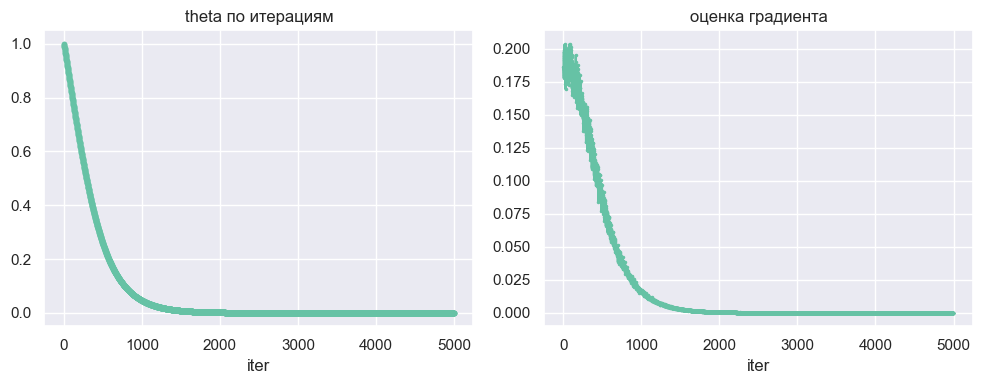

In [38]:
from tqdm.notebook import tqdm

def grad(theta, n):

    ksi = sps.norm.rvs(size=n)
    ksi_sq = ksi**2
    eta = sps.poisson.rvs(5, size=n)         
    eta_sqrt = np.sqrt(eta)             
    a = ksi_sq * eta_sqrt

    denom = (1 + theta**2)
    exp_term = np.exp(- a / denom)
    der_g = a * exp_term * (2 * theta) / denom**2

    return der_g.mean()

theta_0 = 1.0       
lr = 0.01            
n_batch = 200       
steps = 5000

theta_hist = np.empty(steps)
grad_hist = np.empty(steps)

theta = float(theta_0)
theta_hist[0] = theta
grad_hist[0] = np.nan

for i in tqdm(range(1, steps)):
    g = grad(theta, n_batch)
    theta = theta - lr * g
    theta_hist[i] = theta
    grad_hist[i] = g

print("theta_final =", theta_hist[-1])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(theta_hist, marker='o', markersize=3)
plt.title('theta по итерациям')
plt.xlabel('iter'); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(grad_hist, marker='.', markersize=3)
plt.title('оценка градиента')
plt.xlabel('iter'); plt.grid(True)

plt.tight_layout()
plt.show()

---
### Задача 2.

Вам предлагается смоделировать работу небольшой кофейни ☕, используя метод Монте-Карло для оценки распределения дневной выручки, вероятности убытка и влияния простой маркетинговой акции "счастливый час".

Исходные предположения:
- Рабочий день длится 10 часов. Количество посетителей за 1 час &mdash; случайная величина `n_clients` $\sim \text{Pois}(\lambda)$. Считайте, что в "часы пик" среднее число посетителей $\lambda = 30$, в остальное время $\lambda = 10$. Всего в сутках 4 пиковых часа.
- Каждый покупатель берёт 1 случайный напиток по цене `price` $\sim \text{U}\{150, 200, 250, 300, 350, 400\}$ рублей.
- 5% клиентов требуют возврата, за то что им не понравилось: `refund` $\sim \text{Bern}(0.05)$
- 30% клиентов покупают дополнение в виде пирожного. Его цена 200 рублей.
- Фиксированные расходы кофейни за день (аренда, зарплата, сырьё и пр.) &mdash; 40 тыс. рублей

Создайте необходимый набор скриптов, позволяющий симулировать деятельность кофейни. Используя метод Монте-Карло, ответьте на следующие вопросы:
1. Оцените **распределение чистой прибыли**.
2. Оцените **математическое ожидание** прибыли, **стандартное отклонение**, медиану и квантили уровня 0.1 и 0.9.
3. Оцените **вероятность убытка** за день работы.
4. Сравните два сценария: базовый и с акцией "счастливый час". Условия акции:

    👉 *1 непиковый час в день действует скидка 20% на все напитки, но приток клиентов увеличивается на 50% в течение этого часа.*

    По критериям из пунктов 1-3 вынесите вердикт: нужна ли такая акция.

5. Оцените, насколько можно поднять зарплату сотрудникам, чтобы вероятность убытка не превысила 0.4 (экспериментально).

>❗*Замечания*❗
> * Для статистической значимости выводов необходимо делать оценку доверительных интервалов, с которыми вы познакомитесь далее в курсе. Сейчас достаточно сделать точечные оценки.
> * Обычно эффект от акций и прочих нововведений оценивают посредством проведения AB-тестирования. Однако, предварительные простые оценки с целью "разведки" можно провести и при помощи метода Монте-Карло. Это значительно проще, быстрее и дешевле.

In [171]:
def day_revenue(rng, has_promo=False, cost=40_000):
    revenue = 0.0
    working_hours = np.arange(8, 18)
    hot_hours = {8, 9, 13, 14}
    hot_lambda = 10
    reg_lambda = 30
    
    promo_hour = 17
    promo_price_multiplier = 0.8
    promo_client_multiplier = 1.5

    normal_prices = np.arange(150, 450, 50)                
    promo_prices = np.round(normal_prices * promo_price_multiplier).astype(int)
    
    for hour in working_hours:
        lam = hot_lambda if hour in hot_hours else reg_lambda
        
        if has_promo and hour == promo_hour:
            n_clients = int(rng.poisson(lam * promo_client_multiplier))
            prices = promo_prices
        else:
            n_clients = int(rng.poisson(lam))
            prices = normal_prices
            
        if n_clients > 0:
            purchs = rng.choice(prices, size=n_clients)
            revenue += purchs.sum()
            n_refund = int(rng.binomial(n_clients, 0.05))
            if n_refund > 0:
                revenue -= rng.choice(purchs, size=n_refund, replace=False).sum()
            n_others = int(rng.binomial(n_clients, 0.3))
            revenue += n_others * 200
            
    revenue -= cost
    return revenue

  0%|          | 0/100000 [00:00<?, ?it/s]

n_sim = 100000
Средняя выручка: 30,666.48
Стандартное отклонение: 5,184.76
Медиана: 30,600.00
P(revenue < 0) = 0.0000
5%-перцентиль = 22,250.00, 95%-перцентиль = 39,300.00


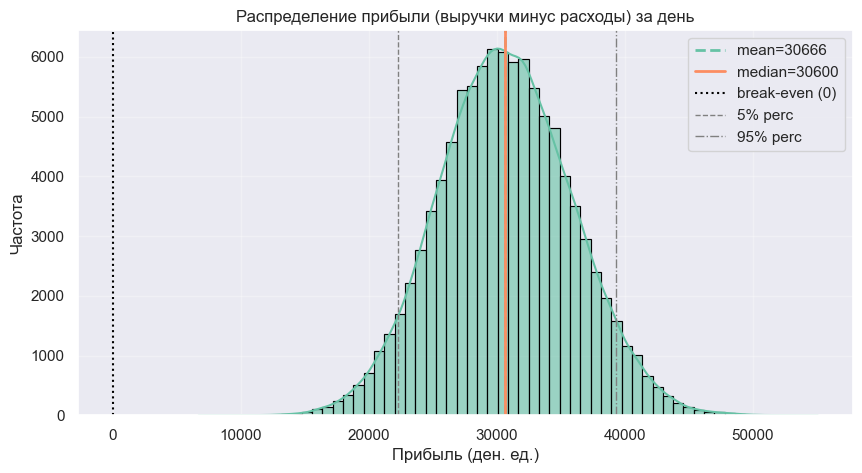

In [165]:
rng = np.random.default_rng(RANDOM_STATE)
n_sim = 100_000
revenues = np.empty(n_sim)
for i in tqdm(range(n_sim)):
    revenues[i] = day_revenue(rng)

mean_rev = revenues.mean()
std_rev = revenues.std(ddof=1)
median_rev = np.median(revenues)
p_loss = np.mean(revenues < 0)
perc_5 = np.percentile(revenues, 5)
perc_95 = np.percentile(revenues, 95)

print(f"n_sim = {n_sim}")
print(f"Средняя выручка: {mean_rev:,.2f}")
print(f"Стандартное отклонение: {std_rev:,.2f}")
print(f"Медиана: {median_rev:,.2f}")
print(f"P(revenue < 0) = {p_loss:.4f}")
print(f"5%-перцентиль = {perc_5:,.2f}, 95%-перцентиль = {perc_95:,.2f}")

plt.figure(figsize=(10,5))
sns.histplot(revenues, bins=60, edgecolor='k', alpha=0.6, kde=True)
plt.axvline(mean_rev, linestyle='--', linewidth=2, label=f"mean={mean_rev:.0f}")
plt.axvline(median_rev, color='C1', linestyle='-', linewidth=2, label=f"median={median_rev:.0f}")
plt.axvline(0, color='k', linestyle=':', linewidth=1.5, label="break-even (0)")
plt.axvline(perc_5, color='gray', linestyle='--', linewidth=1, label="5% perc")
plt.axvline(perc_95, color='gray', linestyle='-.', linewidth=1, label="95% perc")
plt.title("Распределение прибыли (выручки минус расходы) за день")
plt.xlabel("Прибыль (ден. ед.)")
plt.ylabel("Частота")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

  0%|          | 0/100000 [00:00<?, ?it/s]

n_sim = 100000
Средняя выручка: 33,115.84
Стандартное отклонение: 5,205.93
Медиана: 33,070.00
P(revenue < 0) = 0.0000
5%-перцентиль = 24,660.00, 95%-перцентиль = 41,790.00


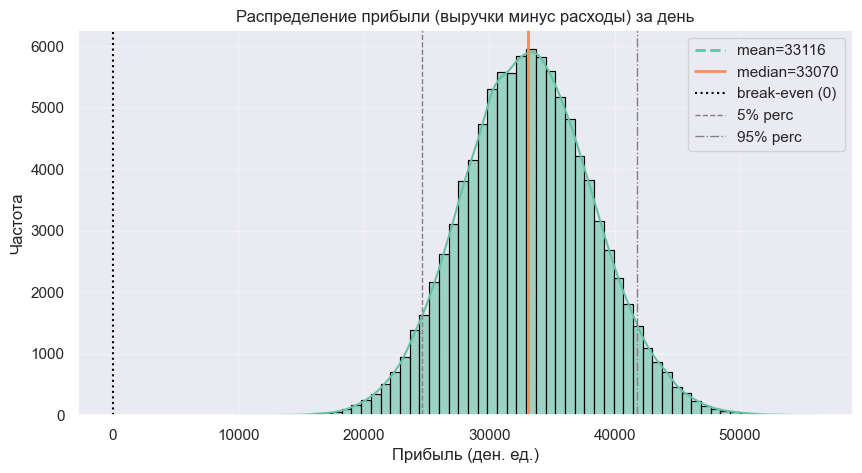

In [168]:
promo_n_sim = 100_000
promo_revenues = np.empty(n_sim)
for i in tqdm(range(n_sim)):
    promo_revenues[i] = day_revenue(rng, has_promo=True)

promo_mean_rev = promo_revenues.mean()
promo_std_rev = promo_revenues.std(ddof=1)
promo_median_rev = np.median(promo_revenues)
promo_p_loss = np.mean(promo_revenues < 0)
promo_perc_5 = np.percentile(promo_revenues, 5)
promo_perc_95 = np.percentile(promo_revenues, 95)

print(f"n_sim = {promo_n_sim}")
print(f"Средняя выручка: {promo_mean_rev:,.2f}")
print(f"Стандартное отклонение: {promo_std_rev:,.2f}")
print(f"Медиана: {promo_median_rev:,.2f}")
print(f"P(revenue < 0) = {promo_p_loss:.4f}")
print(f"5%-перцентиль = {promo_perc_5:,.2f}, 95%-перцентиль = {promo_perc_95:,.2f}")

plt.figure(figsize=(10,5))
sns.histplot(promo_revenues, bins=60, edgecolor='k', alpha=0.6, kde=True)
plt.axvline(promo_mean_rev, linestyle='--', linewidth=2, label=f"mean={promo_mean_rev:.0f}")
plt.axvline(promo_median_rev, color='C1', linestyle='-', linewidth=2, label=f"median={promo_median_rev:.0f}")
plt.axvline(0, color='k', linestyle=':', linewidth=1.5, label="break-even (0)")
plt.axvline(promo_perc_5, color='gray', linestyle='--', linewidth=1, label="5% perc")
plt.axvline(promo_perc_95, color='gray', linestyle='-.', linewidth=1, label="95% perc")
plt.title("Распределение прибыли (выручки минус расходы) за день")
plt.xlabel("Прибыль (ден. ед.)")
plt.ylabel("Частота")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [183]:
rng = np.random.default_rng(RANDOM_STATE)
n_sim = 10_000
revenues = np.empty(n_sim)
for i in tqdm(range(n_sim)):
    revenues[i] = day_revenue(rng, cost=69_300)

mean_rev = revenues.mean()
std_rev = revenues.std(ddof=1)
median_rev = np.median(revenues)
p_loss = np.mean(revenues < 0)
perc_5 = np.percentile(revenues, 5)
perc_95 = np.percentile(revenues, 95)

print(f"n_sim = {n_sim}")
print(f"Средняя выручка: {mean_rev:,.2f}")
print(f"Стандартное отклонение: {std_rev:,.2f}")
print(f"Медиана: {median_rev:,.2f}")
print(f"P(revenue < 0) = {p_loss:.4f}")
print(f"5%-перцентиль = {perc_5:,.2f}, 95%-перцентиль = {perc_95:,.2f}")

  0%|          | 0/10000 [00:00<?, ?it/s]

n_sim = 10000
Средняя выручка: 1,368.45
Стандартное отклонение: 5,146.41
Медиана: 1,300.00
P(revenue < 0) = 0.3987
5%-перцентиль = -7,002.50, 95%-перцентиль = 9,850.00


Можно допустить повышение убытков до 69_300. Это 29_300 разницы в день

___
### Задача 3.

Рассмотрим проект по разработке нефтяного месторождения. В основе модели проекта лежат предварительные данные о величине резервов месторождения.

*Замечание.* Знания физики или экономики не требуются, нужно только внимательно прочитать и расписать все семплирования.



*Формулировка задачи от заказчика:*
Общая задача анализа &mdash; основываясь на величине запасов и проценте нефтеотдачи рассчитать NPV (чистая приведенная стоимость) проекта, а точнее, $0.1$-квантиль ее распределения.
Следующим этапом мы хотим использовать ее в качестве критерия оптимизации, то есть максимизировать такое значение NPV, которого мы можем достигнуть или превысить с $90\%$-й вероятностью, подобрав при этом оптимальное количество скважин на месторождении.



Предположим, что на месторождении есть $n$ скважин. Эти скважины добывают некоторую смесь, которая состоит из воды, нефти и различных примесей. Доля нефти из добытого материала называется <a href="https://ru.wikipedia.org/wiki/Нефтеотдача">коэффициентом нефтеотдачи</a> $k$. Мы будем считать, что этот коэффициент является одинаковым для всего месторождения и имеет нормальное распределение со средним $42\%$ и стандартным отклонением $1.2\%$.




**Добыча нефти скважиной за год**

<a href="http://vseonefti.ru/upstream/stadii-razrabotki.html">Разработка месторождения</a> включает три этапа:
1. фаза роста добычи &mdash; период введения в работу новых скважин;
2. фаза плато: после достижения определенного уровня добычи, она некоторое время продолжается на постоянном уровне;
3. фаза снижения добычи &mdash; период, когда темпы добычи экспоненциально снижаются с течением времени.


Для упрощения задачи мы пропустим два первых этапа и рассмотрим только последний.


Каждая скважина $j$ характеризуется параметром $q_j$ &mdash; темп добычи из скважины, определяемый объемом вещества (смесь нефти, воды и др.), добываемого скважиной за сутки. Будем считать, что этот параметр является одинаковым для скважины в течении всего периода разработки и имеет нормальное распределение со средним $10$ тыс. баррелей и стандартным отклонением $3$ тыс. баррелей. Темпы добычи для разных скважин считаются независимыми случайными величинами.

Соответственно, за год $t$ скважина добывает $Q_{tj} = 365 \cdot k \cdot q_j \cdot e^{-0.008 \cdot n \cdot (t-1)}$ тыс. баррелей нефти, где экспонента отвечает за снижение добычи с течением времени.
Всего за год $t$ на месторождении добывается $Q_t = \sum\limits_{j=1}^{n} Q_{tj}$ тыс. баррелей нефти.




**Прибыль**

Стоимость барреля нефти будем считать постоянной и равной $c = 70$ долларов за баррель. Однако, для расчета стоимости нужно учесть <a href="https://ru.wikipedia.org/wiki/Ставка_дисконтирования">ставку дисконтирования</a> &mdash; процентная ставка, используемая для пересчета будущих потоков доходов в единую величину текущей стоимости (см. формулу далее). Обозначим ее $i$ и будем считать, что она имеет нормальное распределение со средним $10\%$ и стандартным отклонением $1.2\%$.

Стоимость добытой нефти за год $t$ составит (тыс. баррелей)
$$\frac{c \cdot Q_t}{(1+i)^{t-1}}.$$

Будем считать, что разработка месторождения прекращается, если за год на всем месторождении было добыто менее $100$ тыс. баррелей нефти. Последний год разработки обозначим $T$.




**Затраты**

Затраты на месторождение (кроме скважин) составляют $C_{\text{мест.}} = 200$ млн. долларов в год. Будем считать, что издержки на содержание скважины $j$ за весь период разработки имеют треугольное распределение (<a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.triang.html">scipy.stats.triang</a>) c минимальным значением $90$ млн. долларов, максимальным значением $120$ млн. долларов и модой (наиболее вероятное значение) $100$ млн. долларов. Обозначим эти случайные величины $C^j_{\text{скв.}}$ и будем считать их независимыми.




**NPV**

Теперь мы можем написать формулу NPV
$$NPV = \sum\limits_{t=1}^T \frac{c \cdot Q_t}{(1+i)^{t-1}} - T \cdot C_{\text{мест.}} - \sum\limits_{j=1}^{n} C^j_{\text{скв.}}.$$




**Задание**

С помощью метода Монте-Карло требуется найти число $x$, при котором $$\mathsf{P}(NPV < x) = 0.1.$$

Количество итераций метода должно быть не менее $100\ 000$. На основе проделанных итераций оцените также среднее значение NPV и вероятность, с которой NPV будет положительна. Кроме того, постройте нормированную гистограмму значений NPV с помощью `plt.hist(values, bins=200, density=True)`.



Перечислим еще раз все *случайные величины*:
* Коэффициент нефтеотдачи $k$ имеет нормальное распределение со средним $42\%$ и стандартным отклонением $1.2\%$;
* $q_1, ..., q_{n}$ &mdash; темпы добычи из скважин &mdash; независимые нормальные случайные величины со средним $10$ тыс. баррелей и стандартным отклонением $3$ тыс. баррелей;
* Ставка дисконтирования $i$ имеет нормальное распределение со средним $10\%$ и стандартным отклонением $1.2\%$;
* $C^1_{\text{скв.}}, ..., C^{n}_{\text{скв.}}$ &mdash; затраты на каждую скважину &mdash; независимые  случайные величины, имеющие треугольное распределение c минимальным значением $90$ млн. долларов, максимальным значением $120$ млн. долларов и модой (наиболее вероятное значение) $100$ млн. долларов (используйте `sps.triang(loc=90, c=1/3, scale=30)`).

Параметры считать независимыми.

*Фиксированные параметры*:
* $n = 25$ скважин;
* $365$ дней в году;
* $c=70$ долларов за баррель &mdash; стоимость нефти;
* $100$ тыс. баррелей &mdash; объем добытой нефти за год, при котором разработка месторождения прекращается;
* $200$ млн. долларов в год &mdash; затраты на месторождение.

> ❗*Замечания*❗
> * Все случайные величины надо сгенерировать заранее, до вычисления значений $T$.
> * **Не стоит выводить явную формулу для $T$, не усложняйте себе задачу, используйте цикл по годам**.
> * Запрещается использовать цикл по количеству элементов в выборке.

**Решение:**

In [21]:
def npv(n):
    n_iter = 100_000
    d = 365
    c = 70
    Q_T = 100 # тыс
    C_place = 200 # млн
    
    k = sps.norm.rvs(loc=42, scale =1.2, size=n_iter) / 100
    q = sps.norm.rvs(loc=10, scale=3, size=(n, n_iter)) # тыс
    i = sps.norm.rvs(loc=10, scale=1.2, size=n_iter) / 100
    C = sps.triang.rvs(loc=90, c=1/3, scale=30, size=(n, n_iter)) # млн
    
    qsum = q.sum(axis=0) 
    years = 100
    t = np.arange(1, years+1)[:, None] 
    
    decay = np.exp(-0.008 * n * (t - 1)) 
    
    Q_t = 365.0 * (k[None, :] * qsum[None, :]) * decay 
    
    below = Q_t < Q_T 
    any_below = below.any(axis=0)
    first_below_idx = np.argmax(below, axis=0) 
    T = np.where(any_below, first_below_idx + 1, years)
    
    years_row = np.arange(1, years+1)[:, None] 
    include = years_row <= T[None, :]
    
    discount = (1.0 + i[None, :]) ** (t - 1) 
    revenue_by_year = (c * Q_t / 1000.0) / discount 
    revenue_sum = np.sum(revenue_by_year * include, axis=0) 
    well_cost_total = C.sum(axis=0)
    NPV = revenue_sum - T * C_place - well_cost_total 
    
    quantile_10 = np.quantile(NPV, 0.1)
    mean_NPV = NPV.mean()
    median_NPV = np.quantile(NPV, 0.5)
    std_NPV = NPV.std()
    prob_positive = np.mean(NPV > 0)

    return NPV, quantile_10, mean_NPV, median_NPV, std_NPV, prob_positive

In [17]:
n = 25
NPV, quantile_10, mean_NPV, median_NPV, std_NPV, prob_positive = npv(n)

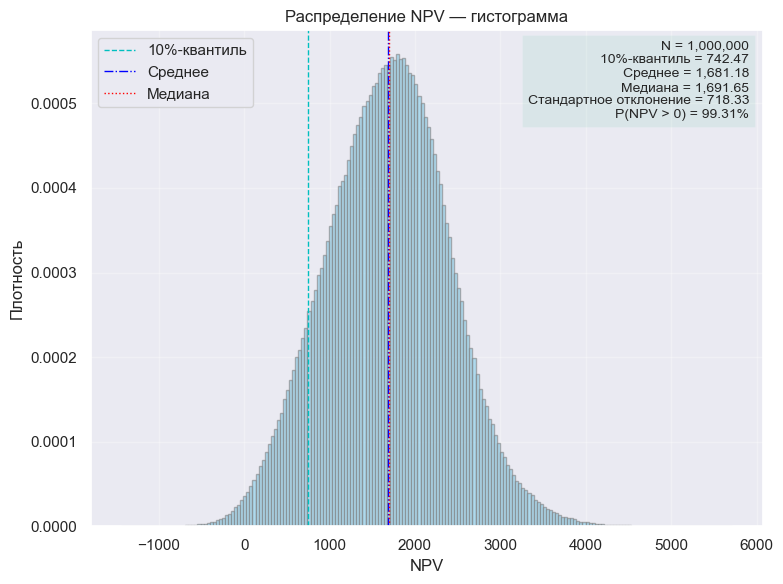

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(NPV, bins=200, density=True, alpha=0.6, color="skyblue", edgecolor="gray")

ax.axvline(quantile_10, linestyle='--', linewidth=1, c='c', label='10%-квантиль')   
ax.axvline(mean_NPV, linestyle='-.', linewidth=1, c='b', label="Среднее")  
ax.axvline(median_NPV, linestyle=':', linewidth=1, c='r', label="Медиана") 

stat_text = (
    f"N = {n_iter:,}\n"
    f"10%-квантиль = {quantile_10:,.2f}\n"
    f"Среднее = {mean_NPV:,.2f}\n"
    f"Медиана = {median_NPV:,.2f}\n"
    f"Стандартное отклонение = {std_NPV:,.2f}\n"
    f"P(NPV > 0) = {prob_positive:.2%}"
)
ax.text(0.98, 0.98, stat_text, transform=ax.transAxes,
        fontsize=10, va='top', ha='right', bbox=dict(alpha=0.12))

ax.set_xlabel("NPV")
ax.set_ylabel("Плотность")
ax.set_title("Распределение NPV — гистограмма")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
quants_10 = []
n_max = 100
n_grid = range(1, n_max + 1)

for n in tqdm(n_grid):
    NPV, quantile_10, mean_NPV, median_NPV, std_NPV, prob_positive = npv(n)
    quants_10.append(quantile_10)

  0%|          | 0/100 [00:00<?, ?it/s]

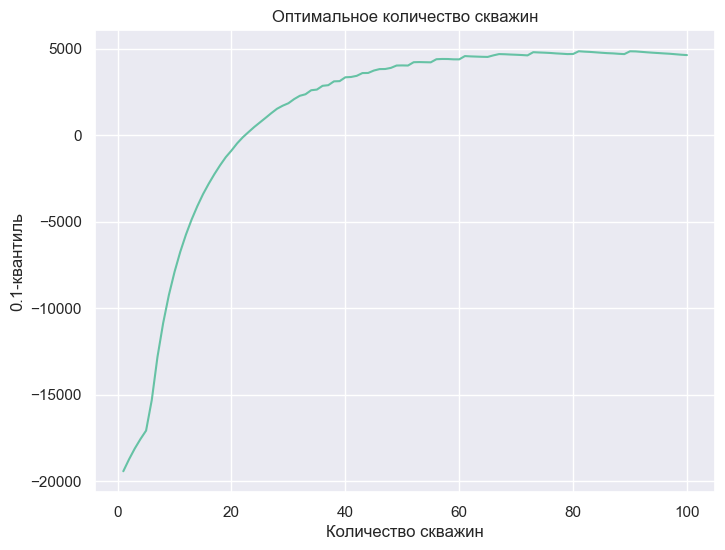

In [30]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_max + 1), quants_10)
plt.xlabel('Количество скважин')
plt.ylabel('0.1-квантиль')
plt.title('Оптимальное количество скважин')
plt.show()

**Вывод:** Учитывая, что на месторождении скважины надо бурить и это тоже стоит денег, оптимальное количество - около 40 (неизвестно сколько стоит бурение, а активный рост становится меньше)